<a href="https://colab.research.google.com/github/9terry-student/ContraMamba/blob/main/ContraMamba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


ContraMamba Toy Experiment

Baseline Energy:
tensor([ 6.9461, 13.8711,  9.9648])

ContraMamba Energy:
tensor([ 6.9461, 13.8711, 19.7425])

Baseline Cosine Similarity:
tensor([1.0000, 0.9985, 0.8669])

ContraMamba Cosine Similarity:
tensor([1.0000, 0.9985, 0.9669])


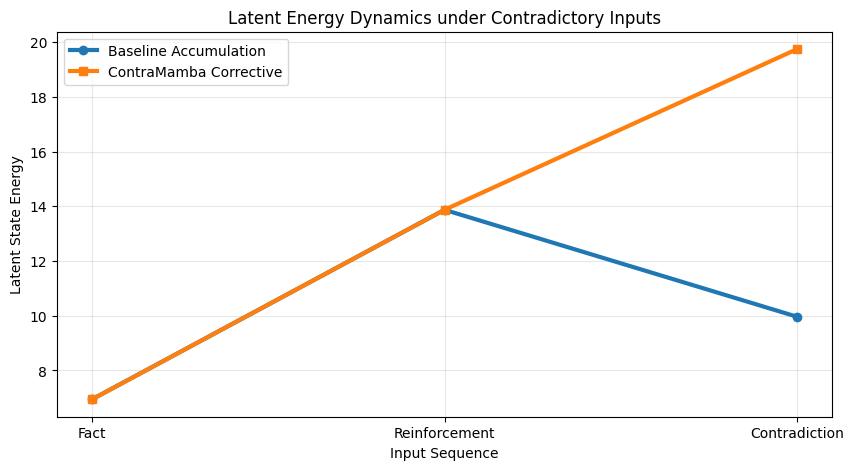

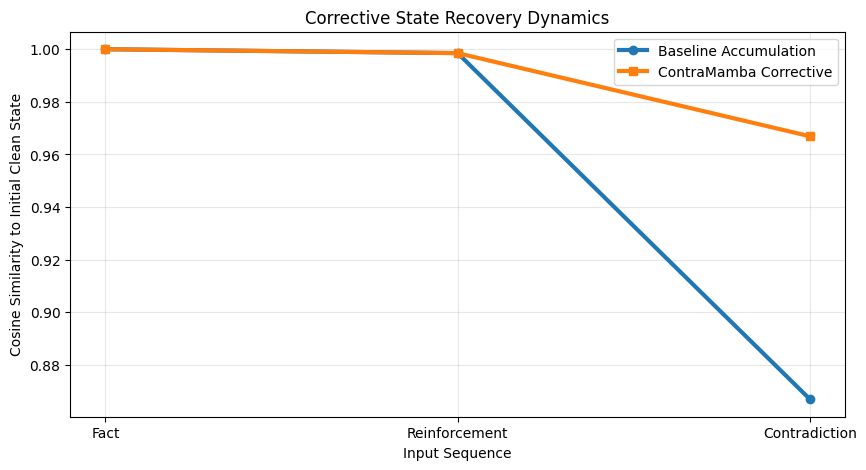

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ============================================================
# ContraMamba Toy Experiment
# Contradiction-Aware Corrective Dynamics Demo
# ============================================================

torch.manual_seed(42)

# ============================================================
# 1. ContraTernaryGate
# ============================================================

class ContraTernaryGate(nn.Module):

    def __init__(self, d_model, hidden_dim=32, threshold=0.25):
        super().__init__()

        self.threshold = threshold

        self.net = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, d_model)
        )

    def forward(self, x):

        # Continuous logits
        logits = torch.tanh(self.net(x))

        # Hard ternary routing
        g_hard = torch.zeros_like(logits)

        g_hard[logits > self.threshold] = 1.0
        g_hard[logits < -self.threshold] = -1.0

        # Straight-Through Estimator (STE)
        g = g_hard - logits.detach() + logits

        return g, logits


# ============================================================
# 2. ContraMambaCore
# ============================================================

class ContraMambaCore(nn.Module):

    def __init__(self, d_model=32, d_state=16):
        super().__init__()

        self.d_model = d_model
        self.d_state = d_state

        # Ternary gate
        self.gate = ContraTernaryGate(d_model)

        # Stable transition dynamics
        self.A = nn.Parameter(
            torch.randn(d_model, d_state) * -0.1
        )

        # Projection geometry
        self.B_proj = nn.Linear(
            d_model,
            d_model * d_state
        )

        # Orthogonal init
        nn.init.orthogonal_(self.B_proj.weight)

    def forward(self, x, forced_gate=None):

        batch, seq, _ = x.shape

        # Initial latent state
        h = torch.zeros(
            batch,
            self.d_model,
            self.d_state
        )

        # Gate routing
        if forced_gate is None:
            g, logits = self.gate(x)
        else:
            g = forced_gate
            logits = None

        # Logs
        energy_history = []
        cosine_history = []
        state_history = []

        clean_reference = None

        for t in range(seq):

            x_t = x[:, t, :]

            # Projection
            Bx = self.B_proj(x_t)

            Bx = Bx.view(
                batch,
                self.d_model,
                self.d_state
            )

            # Gate
            g_t = g[:, t, :].unsqueeze(-1)

            # Stable decay
            A_decay = torch.exp(self.A)

            # ContraMamba update
            h = A_decay * h + g_t * Bx

            # Save clean reference
            if t == 0:
                clean_reference = h.clone()

            # Metrics
            energy = h.norm().item()

            cosine = F.cosine_similarity(
                h.flatten(),
                clean_reference.flatten(),
                dim=0
            ).item()

            energy_history.append(energy)
            cosine_history.append(cosine)
            state_history.append(h.detach().clone())

        return {
            "h": h,
            "energy": torch.tensor(energy_history),
            "cosine": torch.tensor(cosine_history),
            "states": state_history,
            "gate": g,
            "logits": logits
        }


# ============================================================
# 3. Synthetic Contradiction Dataset
# ============================================================

def build_inputs(d_model=32):

    # Base semantic concept
    fact = torch.randn(d_model)

    # Consistent reinforcement
    reinforce = fact + 0.05 * torch.randn(d_model)

    # Contradiction-like input
    contradiction = -fact + 0.2 * torch.randn(d_model)

    x = torch.stack([
        fact,
        reinforce,
        contradiction
    ], dim=0)

    return x.unsqueeze(0)


# ============================================================
# 4. Visualization
# ============================================================

def plot_results(normal_out, contra_out):

    timesteps = [0, 1, 2]

    labels = [
        "Fact",
        "Reinforcement",
        "Contradiction"
    ]

    # --------------------------------------------------------
    # Plot 1 — Latent Energy
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        timesteps,
        normal_out["energy"],
        marker='o',
        linewidth=3,
        label='Baseline Accumulation'
    )

    plt.plot(
        timesteps,
        contra_out["energy"],
        marker='s',
        linewidth=3,
        label='ContraMamba Corrective'
    )

    plt.xticks(timesteps, labels)

    plt.xlabel("Input Sequence")
    plt.ylabel("Latent State Energy")

    plt.title(
        "Latent Energy Dynamics under Contradictory Inputs"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.show()

    # --------------------------------------------------------
    # Plot 2 — State Recovery Similarity
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        timesteps,
        normal_out["cosine"],
        marker='o',
        linewidth=3,
        label='Baseline Accumulation'
    )

    plt.plot(
        timesteps,
        contra_out["cosine"],
        marker='s',
        linewidth=3,
        label='ContraMamba Corrective'
    )

    plt.xticks(timesteps, labels)

    plt.xlabel("Input Sequence")

    plt.ylabel(
        "Cosine Similarity to Initial Clean State"
    )

    plt.title(
        "Corrective State Recovery Dynamics"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.show()


# ============================================================
# 5. Main Experiment
# ============================================================

def run_experiment():

    print("\n====================================")
    print("ContraMamba Toy Experiment")
    print("====================================\n")

    d_model = 32

    model = ContraMambaCore(
        d_model=d_model,
        d_state=16
    )

    x = build_inputs(d_model)

    # --------------------------------------------------------
    # Baseline
    # All updates treated positively
    # --------------------------------------------------------

    g_baseline = torch.ones(1, 3, d_model)

    baseline_out = model(
        x,
        forced_gate=g_baseline
    )

    # --------------------------------------------------------
    # ContraMamba
    # Contradiction receives negative polarity
    # --------------------------------------------------------

    g_contra = torch.ones(1, 3, d_model)

    # Final contradiction token
    g_contra[:, 2, :] = -1.0

    contra_out = model(
        x,
        forced_gate=g_contra
    )

    # --------------------------------------------------------
    # Print Metrics
    # --------------------------------------------------------

    print("Baseline Energy:")
    print(baseline_out["energy"])

    print("\nContraMamba Energy:")
    print(contra_out["energy"])

    print("\nBaseline Cosine Similarity:")
    print(baseline_out["cosine"])

    print("\nContraMamba Cosine Similarity:")
    print(contra_out["cosine"])

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plot_results(
        baseline_out,
        contra_out
    )


# ============================================================
# Run
# ============================================================

run_experiment()